In [10]:
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv("SuperMarket Analysis.csv")
df

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,Giza,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,1:46:00 PM,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,Cairo,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,5:16:00 PM,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,Alex,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,1:22:00 PM,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,Alex,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,3:33:00 PM,Cash,65.82,4.761905,3.2910,4.1


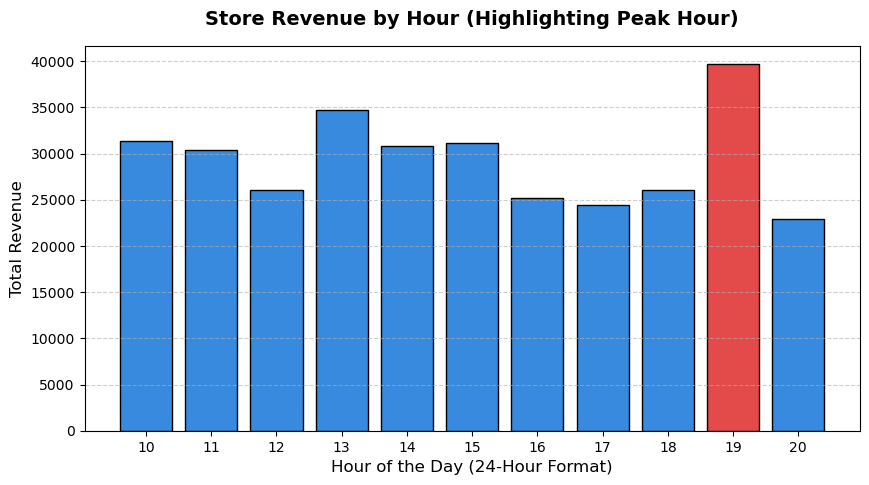

In [14]:
# Plot a bar chart of revenue by hour from yesterday's Q1 output
# x = hourly_revenue.index, height = hourly_revenue.values. This is your first real chart.




# Humari dataset mein Time column mein poora time likha hai (jaise 1:08:00 PM ya 10:29:00 AM). 
#     Hum seedha is par graph nahi bana sakte kyunki har minute alag hota hai. Hum pehle:
# Time column mein se sirf Ghanta (Hour) alag nikalenge (jaise 13, 10, 14 wagera).
# Phir har ghante ki total Sales ko jama (groupby) karke hourly_revenue banayenge.



# Step 1: Pehle Time column ko sahi format mein badlein aur sirf Hour (ghanta) nikalalain



# df['Hour']main table (df) mein ek naya column bana do aur uska naam rakh do Hour.
# pd.to_datetime(...) : Python ke liye aapki file mein likha hua time (1:08:00 PM) 
# sirf ek aam text (string) hai, woh isko time nahi samajhta.
# pd.to_datetime ka kaam is text ko ek asli Time Object mein badalna hai taake Python is par math chala sake.
# df['Time'] : Yeh hamara wo asli column hai jisme 1:08:00 PM jaise times likhe hue hain.
# %I Ghnta , %M MInutes, %S seconds  %p AM ya PM




# Jab Pandas ne text ko asli time mein badal diya, toh humne aakhir mein .dt.hour lagakar bola:
# "Bhai, ab is poore time mein se baki sab choro, bas Ghanta (Hour) nikal lo." 
#     Yeh 1:08:00 PM ko automatic 13 bana dega (24-hour format ke mutabiq).


df['Hour'] = pd.to_datetime(df['Time'], format='%I:%M:%S %p').dt.hour


# Step 2: Har ghante ke mutabiq total Sales calculate karein (Yahan banega hourly_revenue!)




# : Humne Pandas ko bola: "Puri table ko ghanton ke mutabiq alag-alag dheron mein baanto." 
# Yani 13 baje (1 PM) ki saari rows ka ek dher, 14 baje (2 PM) ka alag dher.
# ['Sales'] : Pandas ko bataya ke un dheron mein ja kar sirf Sales (paisa/kamai) wala column uthao.
# .sum() : Pandas se kaha ke har ghante ke dher mein jitni bhi sales hain, un sab ko auras mein plus (+) kar do.
# Nateeja: Ab hourly_revenue ke paas har ek ghante ki total kamai aa gayi.


hourly_revenue = df.groupby('Hour')['Sales'].sum()


# 1. Sabse pehle peak hour dhoondna (Sabse zyada sales wala ghanta)
peak_hour = hourly_revenue.idxmax()


# 2. List comprehension se rangon ki list tayaar karna
colors = ['#E24B4A' if h == peak_hour else '#378ADD' for h in hourly_revenue.index]





# Step 3: Ab aapka Bar Chart banayein
# plt.figure(figsize=(10, 5)) : Yeh graph ka khali board (canvas) tayaar karta hai. figsize=(10, 5) ka matlab hai
# ke chart 10 inch lamba aur 5 inch ooncha hona chahiye taake khula-khula dikhe.

plt.figure(figsize=(10, 5)) # Chart ka size thoda bada karne ke liye



# plt.bar(...) : Yeh Pandas ka function hai jo lambe khambey (bars) banata hai.
# x=hourly_revenue.index : $X\text{-axis}$ (neeche wali line) par kya aayega? hourly_revenue.
#     index ka matlab hai woh ghante (9, 10, 11, 12... se lekar 20, 21 tak).


# eight=hourly_revenue.values : Bars ki oonchai kitni hogi? hourly_revenue.values ka matlab hai
# un ghanton mein hone wali asli kamai (paisa).
# Jis ghante zyada kamai hogi, uska khamba utna hi ooncha ho jayega.


# color='royalblue', edgecolor='black' : Bars ka andar ka rang neela (royalblue) hoga aur unki bahaar 
# ki boundary ka rang kala (black) hoga taake graph dekhne mein professional lage.


plt.bar(x=hourly_revenue.index, height=hourly_revenue.values, color=colors, edgecolor='black')





# Step 4: Title aur Labels lagayein
plt.title('Store Revenue by Hour (Highlighting Peak Hour)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hour of the Day (24-Hour Format)', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)


# X-axis par saare ghante saaf dikhane ke liye
plt.xticks(hourly_revenue.index)

# Background grid lines
# plt.xticks(hourly_revenue.index) : Agar yeh na likhein toh Python kabhi 
# kabhi beech ke ghante (jaise 11, 13, 15) chupa deta hai. 
#  Yeh line likhne se $X\text{-axis}$ par har ek ghanta (9, 10, 11, 12...) saaf-saaf likha hua aayega.



# plt.grid(axis='y', linestyle='--', alpha=0.6) : Yeh chart ke background mein halki si dharidar (--) lines laga
# deta hai taake door se dekh kar andaza ho sake ke bar kis level tak ja raha hai. alpha=0.6 isko
# bohot tez hone se rokta hai (halka rakhta hai).

plt.grid(axis='y', linestyle='--', alpha=0.6)


# plt.savefig() Yeh Matplotlib ka function hai jo screen par dikhne wale chart ko computer mein ek permanent file bana kar save kar deta hai
# (Jaise hum normal MS Word mein Ctrl + S daba kar file save karte hain)

# Anjaam (Filename): Yeh hamari file ka naam hai jo save hogi. .png ka matlab hai Portable Network Graphics—yeh 
# images ka ek behtareen format hota hai jo charts ke rangon ko kharab nahi hone deta.


# DPI (Dots Per Inch): Yeh image ki sharpness (quality) ko barha deta hai. Default image thodi dhundli (blurry)
# lag sakti hai, lekin dpi=150 karne se pixels barh jate hain aur aapka chart bilkul crystal clear aur sharp
# ho jata hai. Agar aap isay kisi bari screen par bhi open karenge, toh text phatega nahi.



# BBox (Bounding Box): Yeh bohot chalak setting hai! Kabhi-kabhi jab hum chart save karte hain, 
# toh side ke labels (jaise 'Total Revenue' ya ghante wale numbers) border se baahar nikal kar kat jate hain.
# bbox_inches='tight' lagane se Python image ke aaspas ki extra khali jagah ko kaat (crop kar) deta hai
# aur poore chart ko bilkul tight aur sahi tarike se fit karke save karta hai taake koi word kate nahi.
plt.savefig('revenue_by_hour.png', dpi=150, bbox_inches='tight')



# Chart display karein
plt.show()


In [15]:
# Plot daily revenue as a line chart — x = day of week, y = revenue
# Sort days in calendar order, not alphabetical. Use: day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

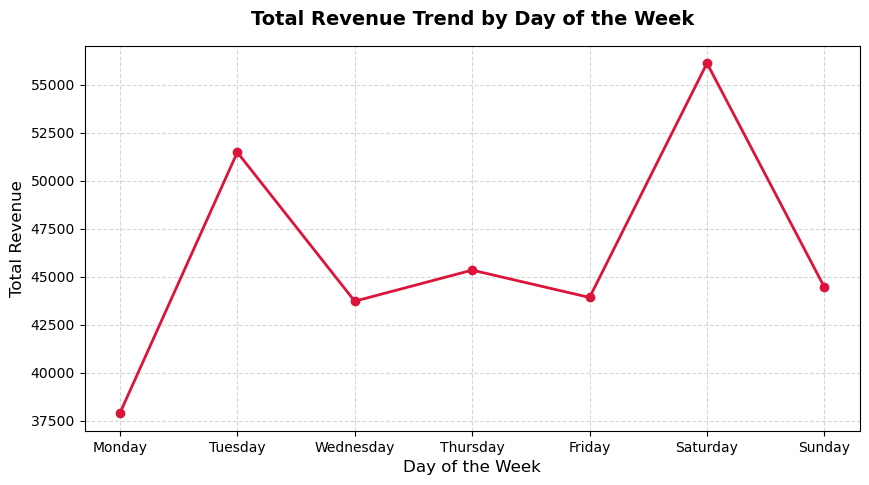

In [16]:
# Sabse bada challenge: Agar hum seedha groupby karenge, toh Pandas days ko Alphabetical order (A to Z)
# mein set kar dega (yani Friday pehle, Monday baad mein). Humein usay Calendar order (Monday se Sunday) 
# mein tarteeb dena hai, jo aapne day_order bataya hai.

# Step 1: Date column se Day Name (Monday, Tuesday...) nikalna
# (Kyunki humari dataset mein Date column '1/5/2019' format mein hai)


# df['Day_of_Week'] = ... : Hum Pandas ko bol rahe hain ke hamari main table (df)
# mein ek naya khali column bana do jiska naam rakhna hai Day_of_Week.

# pd.to_datetime(df['Date']) : humari excel/CSV file mein jo tareekh likhi hui hai (jaise 1/5/2019),
# Python usay abhi ek aam text samajh raha hai. Yeh function us text ko ek asli Date Object mein badalta 
# hai taake Python ko pata chale ke yeh waqai ek calendar ki date hai.


# .dt.day_name() : Jab Pandas tareekh ko samajh leta hai, toh yeh aakhri jaadui function chalte hi woh calendar
# check karta hai aur khud nikaal leta hai ke us date ko kaun sa din tha—jaise Monday, Tuesday, 
# ya Wednesday—aur unhe naye column mein daal deta hai.

# df.groupby('Day_of_Week') : Humne Pandas se kaha: "Poore data ko dinon ke mutabiq alag-alag dheron (groups) 
# mein baanto." Yani saare Mondays ka data ek dher mein, Tuesdays ka dusre mein, aur isi tarah baaki dinon ka bhi.


# ['Sales'] : Un dheron mein se humne sirf Sales (kamai) wala column pakra.

# .sum() : Pandas ne har din ke dher mein maujood saari sales ko aapas mein plus (+) kar diya.

# Masla (Problem): Pandas ne plus toh kar diya, lekin usne dinon ko Alphabetical order 
# (ABC ke mutabiq) set kar diya. Yani aapka data Friday, Monday, Saturday... is tarah aada-tedha save ho gaya.

# day_order = [...] : Humne khud ek simple list banayi jisme hafte ke saare dinon ko sahi sequence (Monday se Sunday) mein likh diya.

# daily_revenue.reindex(day_order) : reindex ka matlab hota hai nayi tarteeb dena. Humne Pandas ko bola:
# "Bhai, apna ABC wala dimaag band karo, aur is data ko usi tarteeb se set karo jo list (day_order) 
# maine tumhein di hai." * Nateeja: Ab aapka data bilkul calendar ke mutabiq Monday, Tuesday, Wednesday... save ho gaya.

df['Day_of_Week'] = pd.to_datetime(df['Date']).dt.day_name()


# Step 2: Har din ke mutabiq total Sales calculate karna
daily_revenue = df.groupby('Day_of_Week')['Sales'].sum()


# Step 3: Alphabetical order ko khatam karke Calendar Order mein sort karna
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_revenue = daily_revenue.reindex(day_order)

# Step 4: Line Chart plot karna (x = days, y = revenue)
plt.figure(figsize=(10, 5))
plt.plot(daily_revenue.index, daily_revenue.values, marker='o', color='crimson', linewidth=2, linestyle='-')

# Step 5: Sajawat (Title, Labels, aur Grid)
plt.title('Total Revenue Trend by Day of the Week', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)

# Background lines lagana (Line chart mein full grid bohot achi lagti hai)
plt.grid(True, linestyle='--', alpha=0.5)

# High-quality image save karna client ke liye
plt.savefig('revenue_by_day.png', dpi=150, bbox_inches='tight')

plt.show()


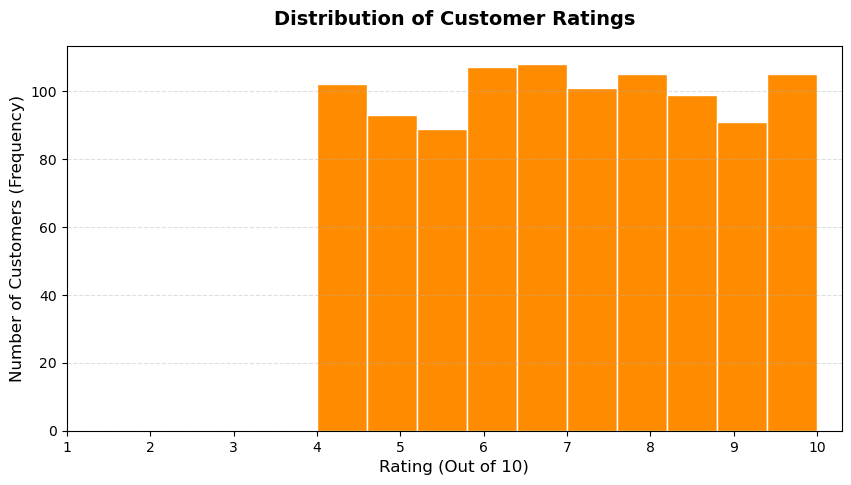

In [17]:
# 1. Histogram plot karna (Aapke bataye hue bins aur edgecolor ke saath)
plt.figure(figsize=(10, 5))
plt.hist(df['Rating'], bins=10, color='darkorange', edgecolor='white')

# 2. Sajawat (Title, Labels, aur Grid)
plt.title('Distribution of Customer Ratings', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Rating (Out of 10)', fontsize=12)
plt.ylabel('Number of Customers (Frequency)', fontsize=12)

# X-axis par 1 se 10 tak saare numbers dikhane ke liye
plt.xticks(range(1, 11))

# Background grid lines
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Client ke liye image save karna
plt.savefig('ratings_histogram.png', dpi=150, bbox_inches='tight')

# Rating 4 se 4.6 tak (Pehla Khamba): Pandas ne gina toh use pata chala ke lagbhag 102 customers hain jinhone 4 se 4.6 ke beech rating di.
# Isliye pehle khambe ki oonchai $Y\text{-axis}$ par 100 se thodi si upar chali gayi.

# Display chart
plt.show()

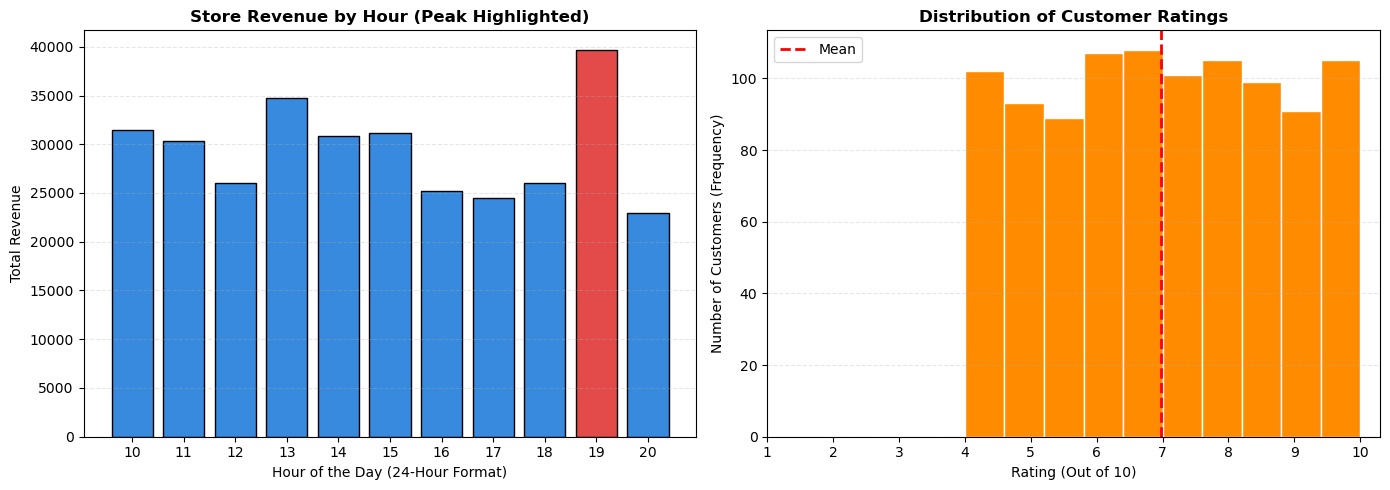

In [19]:
# Create a 1-row, 2-column subplot: bar chart left, histogram right
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5)). Use ax1.bar() and ax2.hist()


# --- 0. DATA PREPARATION (Pehle data tayaar kar lein) ---
df['Hour'] = pd.to_datetime(df['Time'], format='%I:%M:%S %p').dt.hour
hourly_revenue = df.groupby('Hour')['Sales'].sum()
peak_hour = hourly_revenue.idxmax()
colors = ['#E24B4A' if h == peak_hour else '#378ADD' for h in hourly_revenue.index]


# --- 1. SUBPLOT BOARD TAYAAR KARNA ---
# 1 row (ek deewar) aur 2 columns (do kamre)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(x=hourly_revenue.index, height=hourly_revenue.values, color=colors, edgecolor='black')
ax1.set_title('Store Revenue by Hour (Peak Highlighted)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Hour of the Day (24-Hour Format)', fontsize=10)
ax1.set_ylabel('Total Revenue', fontsize=10)
ax1.set_xticks(hourly_revenue.index)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# --- 3. RIGHT SIDE CHART: Histogram (ax2) ---
ax2.hist(df['Rating'], bins=10, color='darkorange', edgecolor='white')
ax2.set_title('Distribution of Customer Ratings', fontsize=12, fontweight='bold')
ax2.set_xlabel('Rating (Out of 10)', fontsize=10)
ax2.set_ylabel('Number of Customers (Frequency)', fontsize=10)
ax2.set_xticks(range(1, 11))
ax2.grid(axis='y', linestyle='--', alpha=0.3)



# Q4
# Add a horizontal red dashed line at the mean rating
# ax2.axvline(df['Rating'].mean(), color='red', linestyle='--', label='Mean')


# ax2: Hum Python ko bata rahe hain ke yeh line dusre plot (Right side wale Histogram) par lagani hai, left wale bar chart par nahi.
# axvline: (Axis Vertical Line) Yeh pure graph ke upar se neeche tak ek khari line khinch dega.

# df['Rating'].mean()Kahan lagani hai? Yeh line ki position tay karta hai. .mean() ka matlab hai average. 
#  Python poore column ki ratings ka average nikaal kar (misaal ke taur par 6.97), yeh line $X\text{-axis}$ par bilkul
# 6.97 ke upar khari kar dega.

# label='Mean'
# Yeh line ka naam rakh raha hai. Jab hum graph mein Legend (chota sa box jo batata hai kaun si line kis cheez ki hai)
# lagayenge, toh wahan likha hua aayega ke yeh laal line 'Mean' (Average) ko dikha rahi hai.

# 🌟 NEW: Yahan humne average rating ki vertical line lagayi aur legend show kiya
ax2.axvline(df['Rating'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
ax2.legend() # Yeh line lagana zaroori hai taake 'Mean' ka box nazar raye




# --- 4. FINAL TOUCHES & SAVE ---
# Dono charts ke darmiyan munasib jagah chorna taake labels aapas mein na takrayein
plt.tight_layout()

# Image save karna
plt.savefig('dashboard_subplot.png', dpi=150, bbox_inches='tight')

# Display dashboard
plt.show()